In [10]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as la
from scipy.optimize import minimize
from skimage.feature import peak_local_max

%matplotlib inline

### Question 01

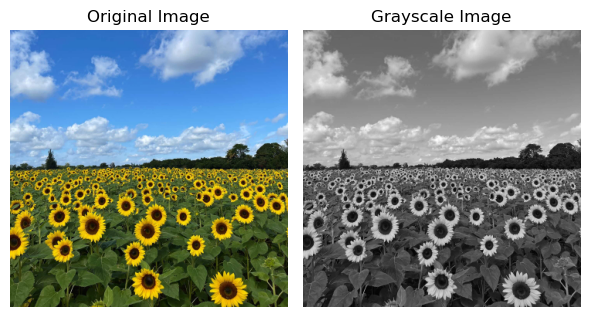

In [11]:
im = cv.imread('a2images/the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
im_rgb = cv.cvtColor(im, cv.COLOR_BGR2RGB)
im_gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY)

fig, axs = plt.subplots(1, 2, figsize=(6, 6))
axs[0].imshow(im_rgb)
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(im_gray, cmap='gray')
axs[1].set_title('Grayscale Image')
axs[1].axis('off')
plt.tight_layout()
plt.show()

In [12]:
h, w = im_gray.shape
sigmas = np.arange(1,11,1)

scale_space = np.empty((h, w, len(sigmas)), dtype=np.float32)
for i, sigma in enumerate(sigmas):
    log_hw = 3 * sigma
    X, Y = np.meshgrid(np.arange(-log_hw, log_hw + 1, 1), np.arange(-log_hw, log_hw + 1, 1))
    log = 1/(2*np.pi*sigma**2)*(X**2/(sigma**2) + Y**2/(sigma**2) - 2)*np.exp(-(X**2 + Y**2)/(2*sigma**2))
    f_log = cv.filter2D(im_gray, -1, log)
    scale_space[:, :, i] = f_log
local_maxima_coords = peak_local_max(scale_space, footprint=np.ones((3, 3, len(sigmas))), threshold_rel=0.7)

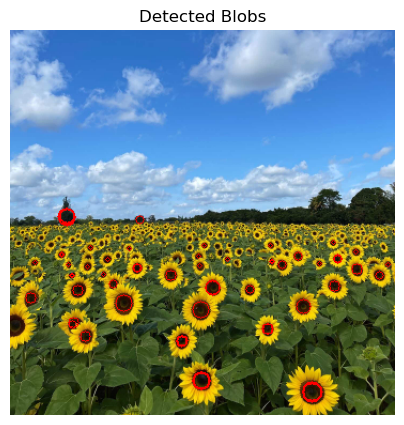

Max radius is: 9
Max circle in: (282, 337)


In [13]:
# plot circles on original image
max_radius = 0
max_cood = tuple()
im_with_circles = im_rgb.copy()
for coord in local_maxima_coords:
    y, x, sigma_idx = coord
    sigma = sigmas[sigma_idx]
    radius = int(np.sqrt(2) * sigma)
    if radius > max_radius:
        max_radius = radius
        max_cood = (x, y)
    cv.circle(im_with_circles, (x, y), radius, (255, 0, 0), 1)
plt. figure(figsize=(5,5))
plt.imshow(im_with_circles)
plt.axis('off')
plt.title('Detected Blobs')
plt.show()

print(f"Max radius is: {max_radius}")
print(f"Max circle in: {max_cood}")

### Question 02

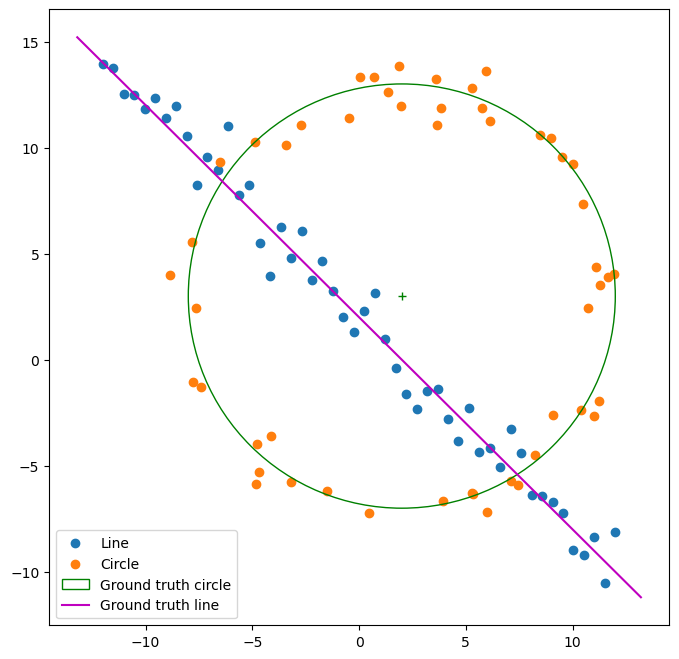

In [14]:
# Generation of a Noisy Point Set Conforming to a Line and a Circle
import numpy as np
from scipy.optimize import minimize
from scipy import linalg
import matplotlib.pyplot as plt
import tikzplotlib

# np.random.seed(0)
N= 100
half_n =N//2
r = 10
x0_gt , y0_gt = 2, 3 # Center
s = r/16
t = np.random.uniform(0, 2*np.pi , half_n)
n = s*np.random.randn(half_n)
x, y = x0_gt + (r + n)*np.cos(t), y0_gt + (r + n)*np.sin(t)
X_circ = np.hstack((x.reshape(half_n ,1) , y.reshape(half_n ,1)))

s = 1.
m, b = -1, 2
x = np.linspace(-12, 12, half_n)
y = m*x + b + s*np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n ,1) , y.reshape(half_n ,1)))
X = np.vstack((X_circ , X_line )) # All points

fig , ax = plt.subplots(1,1, figsize =(8 ,8))

ax.scatter(X_line[:, 0], X_line[:, 1], label='Line')
ax.scatter(X_circ[:, 0], X_circ[:, 1], label='Circle')
circle_gt = plt.Circle((x0_gt, y0_gt), r, color='g', fill=False, label='Ground truth circle')
ax.add_patch(circle_gt)

ax.plot((x0_gt), (y0_gt), '+', color='g')
x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m*x_ + b
plt.plot(x_, y_, color='m', label='Ground truth line')
plt.legend()

### RANSAC

In [15]:
def line_TLS(x, indices):
    a, b, d = x[0], x[1], x[2]
    return np.sum(np.square(a*X_line[indices, 0] + b*X_line[indices, 1] - d))

def circle_TLS(x, indices):
    x0, y0, r = x[0], x[1], x[2]
    return np.sum(np.square(np.sqrt((X_circ[indices, 0] - x0)**2 + (X_circ[indices, 1] - y0)**2) - r))

def cons(x):
    return x[0]**2 + x[1]**2 - 1
constr = {'type': 'eq', 'fun': cons}

def consensus_line(X, x, threshold):
    a, b, d = x[0], x[1], x[2]
    dists = np.abs(a*X[:, 0] + b*X[:, 1] - d)
    return dists < threshold

def consensus_circle(X, x, threshold):
    x0, y0, r = x[0], x[1], x[2]
    dists = np.abs(np.sqrt((X[:, 0] - x0)**2 + (X[:, 1] - y0)**2) - r)
    return dists < threshold



### RANSAC for Line

In [16]:
# Data and Parameters
X_line = X
N_line = X_line.shape[0]

# RANSAC for line fitting
threshold = 1.
dp = 0.35 * N_line # 35% of points needed to assert a good model
s = 2 # Minimum points to fit a model

max_iters = 1000
iterations = 0
inliers_line = []          # Line inliers
best_model_line = []       # RANSAC line
best_sample_line = []      # Best sample for line
best_error_line = np.inf
res_only_with_sample_line = []
best_inliers_line = []

for iterations in range(max_iters):
    indices = np.random.randint(0, N_line, s)
    x0 = np.array([1, 1, 0]) # Initial guess
    res = minimize(fun=line_TLS, x0=x0, args=indices, tol=1e-6, constraints=constr)
    if res.success:
        inliers_line = consensus_line(X_line, res.x, threshold)
        n_inliers = np.sum(inliers_line)

        if n_inliers > dp:
            
            x0 = res.x
            res = minimize(fun=line_TLS, x0=x0, args=inliers_line, tol=1e-6, constraints=constr)
            
            if res.fun < best_error_line:
                best_error_line = res.fun
                best_model_line = res.x
                best_sample_line = X_line[indices, :]
                best_inliers_line = inliers_line
                res_only_with_sample_line = x0

print("Best model for line (a, b, d):", best_model_line)


Best model for line (a, b, d): [0.72343465 0.69039286 1.10543458]


### RANSAC for Circle

In [ ]:
# Data and Parameters
X_circ = X[~best_inliers_line]   # Remove the consensus of the best line
N_circ = X_circ.shape[0]

# RANSAC for circle fitting
threshold = 1.
dp = 0.3 * N_circ   # 30% of points needed to assert a good model
s = 3               # Minimum points to fit a model

max_iters = 1000
iterations = 0
inliers_circ = []          # Circle inliers
best_model_circ = []       # RANSAC circle
best_sample_circ = []      # Best sample for circle
best_error_circ = np.inf
res_only_with_sample_circ = []
best_inliers_circ = []

while iterations < max_iters:
    indices = np.random.randint(0, N_circ, s)
    x0 = np.array([1, 1, 1])  # Initial guess
    res = minimize(fun=circle_TLS, x0=x0, args=indices, tol=1e-6)
    if res.success:
        inliers_circ = consensus_circle(X_circ, res.x, threshold)
        n_inliers = np.sum(inliers_circ)
      
        if n_inliers > dp:
            x0 = res.x
            res = minimize(fun=circle_TLS, x0=x0, args=inliers_circ, tol=1e-6)
            
            if res.fun < best_error_circ:
                best_error_circ = res.fun
                best_model_circ = res.x
                best_sample_circ = X_circ[indices, :]
                best_inliers_circ = inliers_circ
                res_only_with_sample_circ = x0
                
    iterations += 1

print("Best model for circle (a, b, r):", best_model_circ)


Best model for circle (a, b, r): [1.1782487  4.09587988 9.96720385]


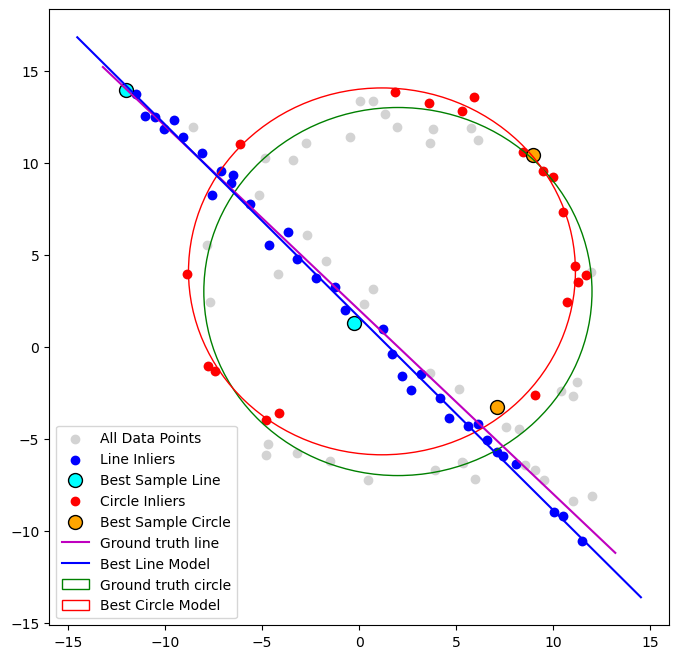

In [18]:
# Plotting the results
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# All data points
ax.scatter(X[:, 0], X[:, 1], label='All Data Points', color='lightgray')

# Line inliers
ax.scatter(X_line[best_inliers_line, 0], X_line[best_inliers_line, 1], label='Line Inliers', color='blue')
# Best sample for line
ax.scatter(best_sample_line[:, 0], best_sample_line[:, 1], label='Best Sample Line', color='cyan', edgecolor='black', s=100, marker='o')

# Circle inliers
ax.scatter(X_circ[best_inliers_circ, 0], X_circ[best_inliers_circ, 1], label='Circle Inliers', color='red')
# Best sample for circle
ax.scatter(best_sample_circ[:, 0], best_sample_circ[:, 1], label='Best Sample Circle', color='orange', edgecolor='black', s=100, marker='o')

# Plotting Ground Truth line
x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m*x_ + b
plt.plot(x_, y_, color='m', label='Ground truth line')

# Plotting the best line model
x_vals = np.array(ax.get_xlim())
m = (-best_model_line[0]/best_model_line[1])
c = (best_model_line[2]/best_model_line[1])
y_vals = m * x_vals + c
ax.plot(x_vals, y_vals, color='blue', label='Best Line Model')

# Plotting Ground Truth circle
circle_gt = plt.Circle((x0_gt, y0_gt), r, color='g', fill=False, label='Ground truth circle')
ax.add_patch(circle_gt)

# Plotting the best circle model
circle = plt.Circle((best_model_circ[0], best_model_circ[1]), best_model_circ[2], color='red', fill=False, label='Best Circle Model')
ax.add_artist(circle)

ax.legend()

## Question 03